In [1]:
import os
os.environ['R_HOME'] = '/home/yanxh/anaconda3/envs/R4.3/lib/R'
os.environ['R_USER'] = '/home/yanxh/anaconda3/envs/R4.3/lib/python3.8/site-packages/rpy2'
import psutil

# Get the current process
# p = psutil.Process(os.getpid())

# # Set the process to run only on the first CPU core
# p.cpu_affinity([5])

In [2]:
import os
import gc
import pandas as pd
import pickle
import matplotlib.pyplot as plt

import anndata as ad
import numpy as np
import yaml
import sys
import h5py
import logging
import scanpy as sc
from os.path import join
import scipy.sparse as sps
from sklearn.cluster import KMeans

import scglue

import warnings
def wrap_warn_plot(adata, basis, color, **kwargs):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)
        sc.pl.embedding(adata, basis=basis, color=color, **kwargs)

def get_umap(ad, use_reps=[]):
    for use_rep in use_reps:
        umap_add_key = f'{use_rep}_umap'
        sc.pp.neighbors(ad, use_rep=use_rep, n_neighbors=15)
        sc.tl.umap(ad)
        ad.obsm[umap_add_key] = ad.obsm['X_umap']
    return ad

from sklearn.metrics import adjusted_rand_score

def split_ob(ads, ad_ref, ob='obs', key='emb2'):
    len_ads = [_.n_obs for _ in ads]
    if ob=='obsm':
        split_obsms = np.split(ad_ref.obsm[key], np.cumsum(len_ads[:-1]))
        for ad, v in zip(ads, split_obsms):
            ad.obsm[key] = v
    else:
        split_obs = np.split(ad_ref.obs[key].to_list(), np.cumsum(len_ads[:-1]))
        for ad, v in zip(ads, split_obs):
            ad.obs[key] = v

def eval_ads(ads, ref_key, src_key):
    aris = []
    for ad in ads:
        aris.append(adjusted_rand_score(ad.obs[src_key], ad.obs[ref_key]))
    return aris

def flip_coords(ads):
    for ad in ads:
        ad.obsm['spatial'] = -1 * ad.obsm['spatial']
        ad.obsm['spatial'] = ad.obsm['spatial'][:, ::-1]

def reorder(ad1, ad2):
    shared_barcodes = ad1.obs_names.intersection(ad2.obs_names)
    ad1 = ad1[shared_barcodes].copy()
    ad2 = ad2[shared_barcodes].copy()
    return ad1, ad2

def load_peak_expr(_dir):
    data = sio.mmread(join(_dir, 'data.mtx'))
    cname = pd.read_csv(join(_dir, 'barcode.csv'), index_col=0)['x'].to_list()
    feat = pd.read_csv(join(_dir, 'feat.csv'), index_col=0)['x'].to_list()
    ad = sc.AnnData(sps.csr_matrix(data.T))
    ad.obs_names = cname
    ad.var_names = feat
    return ad

/home/yanxh/anaconda3/envs/torch112/lib/python3.8/site-packages/setuptools_scm/_integration/setuptools.py:30: RuntimeWarning: 
ERROR: setuptools==59.5.0 is used in combination with setuptools_scm>=8.x

Your build configuration is incomplete and previously worked by accident!
setuptools_scm requires setuptools>=61

Suggested workaround if applicable:
 - migrating from the deprecated setup_requires mechanism to pep517/518
   and using a pyproject.toml to declare build dependencies
   which are reliably pre-installed before running the build tools

  warnings.warn(


In [3]:
def set_col2cat(ad, cols=[]):
    for col in cols:
        ad.obs[col] = ad.obs[col].astype('category')

def unify_colors(queries, color_key, ref_color_dict):
    for q in queries:
        q.obs[color_key] = q.obs[color_key].astype('category')
        q.uns[f'{color_key}_colors'] = [ref_color_dict[_] for _ in q.obs[color_key].cat.categories]
    return queries

def subset_ad(ad, subset_index):
    ad = ad[subset_index].copy()
    return ad

### Training and running

In [4]:
sys.path.insert(0, './resources')
import utils
import scipy.io as sio

In [5]:
out_dir = './cache/DBiT-RNATAC-ATAC'
os.makedirs(out_dir, exist_ok=True)
## best setting for simulation experiments
# n_genes = 10000
# x2u_h_depth = 2
# x2u_h_dim = 512 
# u2x_h_depth = 1
# du_h_depth = 2
# dropout = 0.2
# lam_data = 1.0
# lam_kl = 1.0  
# lam_align = 2.0   
# lam_cross = 2.0 
# lam_cos = 1.0 
# normalize_u = True
# random_seed = 5
# latent_dim = 50
# u2x_h_dim = 256
# du_h_dim  = u2x_h_dim
# du_h_depth = 2

## multiome setting
n_genes = 10000
latent_dim = 50
x2u_h_depth = 2
x2u_h_dim = 512
u2x_h_depth = 1
u2x_h_dim = 256
du_h_depth = 1
du_h_dim = 256
dropout = 0.2
lam_data = 1.0
lam_kl = 0.3
lam_align = 0.02
lam_cross = 1.0
lam_cos = 0.02
normalize_u = True
random_seed = 2

max_epochs1 = 400
max_epochs2 = 50

In [6]:
data_dir = '../../../data/processed/DBiT-RnaAtac-Atac'

ad_db_rna = sc.read_h5ad(join(data_dir, 'DBiT/ad_rna.h5ad'))
ad_db_atac = sc.read_h5ad(join(data_dir, 'DBiT/ad_atac.h5ad'))

ad_sra50_rna = sc.read_h5ad(join(data_dir, 'SpatialRnaAtac-50/ad_rna.h5ad'))
ad_sra50_atac = sc.read_h5ad(join(data_dir, 'SpatialRnaAtac-50/ad_atac.h5ad'))

ad_sra100_rna = sc.read_h5ad(join(data_dir, 'SpatialRnaAtac-100/ad_rna.h5ad'))
ad_sra100_atac = sc.read_h5ad(join(data_dir, 'SpatialRnaAtac-100/ad_atac.h5ad'))

ad_sat = sc.read_h5ad(join(data_dir, 'SpatialAtac/ad_atac.h5ad')) 

In [7]:
ad_rna_all = sc.concat([ad_db_rna, ad_sra50_rna, ad_sra100_rna])
ad_atac_all = sc.concat([ad_db_atac, ad_sra50_atac, ad_sra100_atac, ad_sat])

sc.pp.highly_variable_genes(ad_rna_all, flavor='seurat_v3', n_top_genes=10000, batch_key='Slice')
hvg_names = ad_rna_all.var.query('highly_variable').index.to_numpy()

# ac.pp.tfidf(ad_atac_all, scale_factor=1e4)
sc.pp.highly_variable_genes(ad_atac_all, flavor='seurat_v3', n_top_genes=100000, batch_key='Slice')
hvp_names = ad_atac_all.var.query('highly_variable').index.to_numpy()

del ad_rna_all, ad_atac_all
gc.collect()

275

In [8]:
ad_db_rna = ad_db_rna[:, hvg_names].copy()
ad_sra50_rna = ad_sra50_rna[:, hvg_names].copy()
ad_sra100_rna = ad_sra100_rna[:, hvg_names].copy()

ad_db_atac = ad_db_atac[:, hvp_names].copy()
ad_sra50_atac = ad_sra50_atac[:, hvp_names].copy()
ad_sra100_atac = ad_sra100_atac[:, hvp_names].copy()
ad_sat = ad_sat[:, hvp_names].copy()

In [9]:
(ad_db_rna.obs_names==ad_db_atac.obs_names).all()

True

In [10]:
ad_rna_train = sc.concat([ad_db_rna, ad_sra50_rna, ad_sra100_rna])
ad_atac_train = sc.concat([ad_db_atac, ad_sra50_atac, ad_sra100_atac])

ad_rna_train.layers['counts'] = sps.csr_matrix(ad_rna_train.X)
ad_atac_train.layers['counts'] = sps.csr_matrix(ad_atac_train.X)
ad_sat.X = sps.csr_matrix(ad_sat.X)

ad_rna_train.obs["uid"] = [f"train-{i}" for i in range(ad_rna_train.shape[0])]
ad_atac_train.obs["uid"] = [f"train-{i}" for i in range(ad_atac_train.shape[0])]
ad_sat.obs["uid"] = [f"test-{i}" for i in range(ad_sat.shape[0])]

ad_rna_train.obs['batch'] = ad_rna_train.obs.Slice.to_list()
ad_atac_train.obs['batch'] = ad_atac_train.obs.Slice.to_list()
ad_sat.obs['batch'] = ad_sat.obs.Slice.to_list()

print('Reading `h5ad` files...')
omics = "multiome"

print('Preprocessing GEX...')
gex_prep = utils.GEXPreprocessing(n_comps=100, n_genes=n_genes, merge_adt=omics == "cite")
gex_prep.fit_transform(ad_rna_train)
print('Preprocessing ATAC...')
other_prep = utils.ATACPreprocessing(n_comps=100)
other_prep.fit_transform(ad_atac_train)

with open(os.path.join(out_dir, "prep.pickle"), "wb") as f:
    pickle.dump({
        "gex_prep": gex_prep,
        "other_prep": other_prep
    }, f)

with open(f"{out_dir}/hyperparams.yaml", "w") as f:
    yaml.dump({
        "n_genes": n_genes,
        "latent_dim": latent_dim,
        "x2u_h_depth": x2u_h_depth,
        "x2u_h_dim": x2u_h_dim,
        "u2x_h_depth": u2x_h_depth,
        "u2x_h_dim": u2x_h_dim,
        "du_h_depth": du_h_depth,
        "du_h_dim": du_h_dim,
        "dropout": dropout,
        "lam_data": lam_data,
        "lam_kl": lam_kl,
        "lam_align": lam_align,
        "lam_cross": lam_cross,
        "lam_cos": lam_cos,
        "normalize_u": normalize_u,
        "random_seed": random_seed
    }, f)


Reading `h5ad` files...
Preprocessing GEX...
Preprocessing ATAC...


In [11]:
scglue.models.configure_dataset(
    ad_rna_train, "NB", use_highly_variable=True,
    use_layer="counts", use_rep="X_pca",
    use_batch="batch", use_uid="uid"
)
scglue.models.configure_dataset(
    ad_atac_train, "NB", use_highly_variable=True,
    use_layer="counts", use_rep="X_lsi",
    use_batch="batch", use_uid="uid"
)

print('Building model...')
model = scglue.models.SCCLUEModel(
    {"gex": ad_rna_train, "other": ad_atac_train},
    latent_dim=latent_dim,
    x2u_h_depth=x2u_h_depth,
    x2u_h_dim=x2u_h_dim,
    u2x_h_depth=u2x_h_depth,
    u2x_h_dim=u2x_h_dim,
    du_h_depth=du_h_depth,
    du_h_dim=du_h_dim,
    dropout=dropout,
    shared_batches=False,
    random_seed=random_seed
)

print('Compiling model...')
model.compile(
    lam_data=lam_data, lam_kl=lam_kl, lam_align=lam_align,
    lam_cross=lam_cross, lam_cos=lam_cos, normalize_u=normalize_u,
    domain_weight={"gex": 1, "other": 1}
)

# help(model.fit)
print('Training model...')
model.fit(
    {"gex": ad_rna_train, "other": ad_atac_train}, max_epochs=max_epochs1,
)
model.save(os.path.join(out_dir, "pretrain.dill"))

Building model...
[INFO] autodevice: Using GPU 1 as computation device.
Compiling model...
Training model...
[INFO] SCCLUEModel: Setting `align_burnin` = 40
[INFO] SCCLUEModel: Setting `patience` = 30
[INFO] SCCLUEModel: Setting `reduce_lr_patience` = 10
[INFO] SCCLUETrainer: Using training directory: "/tmp/GLUETMP9d79uu0q"
[INFO] SCCLUETrainer: [Epoch 10] train={'dsc_loss': 0.684, 'gen_loss': 0.82, 'cross_loss': 0.414, 'cos_loss': 0.104, 'x_gex_nll': 0.24, 'x_gex_kl': 0.01, 'x_gex_elbo': 0.243, 'x_other_nll': 0.173, 'x_other_kl': 0.005, 'x_other_elbo': 0.174}, val={'dsc_loss': 0.696, 'gen_loss': 0.813, 'cross_loss': 0.41, 'cos_loss': 0.097, 'x_gex_nll': 0.236, 'x_gex_kl': 0.01, 'x_gex_elbo': 0.239, 'x_other_nll': 0.174, 'x_other_kl': 0.005, 'x_other_elbo': 0.176}, 11.0s elapsed
[INFO] SCCLUETrainer: [Epoch 20] train={'dsc_loss': 0.68, 'gen_loss': 0.795, 'cross_loss': 0.401, 'cos_loss': 0.092, 'x_gex_nll': 0.233, 'x_gex_kl': 0.012, 'x_gex_elbo': 0.237, 'x_other_nll': 0.167, 'x_other_kl

2025-05-18 20:42:42,975 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


[INFO] EarlyStopping: Restoring checkpoint "48"...
[INFO] EarlyStopping: Restoring checkpoint "48"...


In [12]:

# ===============================
#               stage 2
# ===============================

logging.info('Concatenating training and test data...')
input_mod1 = ad.concat(
    {"train": ad_rna_train},
    axis=0, join="outer", merge="same", label="group",
    fill_value=0, index_unique="-"
)
input_mod1.uns["feature_type"] = 'GEX'

input_mod2 = ad.concat(
    {"train": ad_atac_train, "test": ad_sat},
    axis=0, join="outer", merge="same", label="group",
    fill_value=0, index_unique="-"
)
input_mod2.uns["feature_type"] = 'ATAC'

gex, other = input_mod1, input_mod2

logging.info('Reading preprocessors...')
with open(os.path.join(
       out_dir, "prep.pickle"
), "rb") as f:
    prep = pickle.load(f)
    gex_prep = prep["gex_prep"]
    other_prep = prep["other_prep"]

logging.info('Preprocessing...')
gex_prep.transform(gex)
other_prep.transform(other)

logging.info('Fine-tuning model...')
scglue.models.configure_dataset(
    gex, "NB", use_highly_variable=True,
    use_layer="counts", use_rep="X_pca",
    use_batch="batch", use_uid="uid"
)
scglue.models.configure_dataset(
    other, "NB", use_highly_variable=True,
    use_layer="counts", use_rep="X_lsi",
    use_batch="batch", use_uid="uid"
)

with open(os.path.join(
        out_dir, "hyperparams.yaml"
), "r") as f:
    hyperparams = yaml.load(f, Loader=yaml.Loader)

logging.info('Building model...')
model = scglue.models.SCCLUEModel(
    {"gex": gex, "other": other},
    latent_dim=hyperparams["latent_dim"],
    x2u_h_depth=hyperparams["x2u_h_depth"],
    x2u_h_dim=hyperparams["x2u_h_dim"],
    u2x_h_depth=hyperparams["u2x_h_depth"],
    u2x_h_dim=hyperparams["u2x_h_dim"],
    du_h_depth=hyperparams["du_h_depth"],
    du_h_dim=hyperparams["du_h_dim"],
    dropout=hyperparams["dropout"],
    shared_batches=False,
    random_seed=hyperparams["random_seed"]
)
# print(model.net)

logging.info('Adopting pretrained weights...')
model.adopt_pretrained_model(scglue.models.load_model(os.path.join(
    out_dir, "pretrain.dill"
)))

logging.info('Compiling model...')
model.compile(
    lam_data=hyperparams["lam_data"],
    lam_kl=hyperparams["lam_kl"],
    lam_align=hyperparams["lam_align"],
    lam_cross=hyperparams["lam_cross"],
    lam_cos=hyperparams["lam_cos"],
    normalize_u=hyperparams["normalize_u"],
    domain_weight={"gex": 1, "other": 1},
    lr=1e-3  # TODO: Fine-tuning learning rate
)

logging.info('Training model...')
model.fit(
    {"gex": gex, "other": other},
    align_burnin=0, max_epochs=max_epochs2,
    patience=20, reduce_lr_patience=6
)

logging.info('Projecting cell embeddings...')
gex.obsm["X_model"] = model.encode_data("gex", gex)
other.obsm["X_model"] = model.encode_data("other", other)


[INFO] Transferrable: Copied: encoders.0.linear_0.weight


INFO:Transferrable:Copied: encoders.0.linear_0.weight


[INFO] Transferrable: Copied: encoders.0.linear_0.bias


INFO:Transferrable:Copied: encoders.0.linear_0.bias


[INFO] Transferrable: Copied: encoders.0.bn_0.weight


...

INFO:SCCLUETrainer:[Epoch 20] train={'dsc_loss': 0.691, 'gen_loss': 0.752, 'cross_loss': 0.38, 'cos_loss': 0.094, 'x_gex_nll': 0.231, 'x_gex_kl': 0.012, 'x_gex_elbo': 0.234, 'x_other_nll': 0.148, 'x_other_kl': 0.006, 'x_other_elbo': 0.15}, val={'dsc_loss': 0.68, 'gen_loss': 0.757, 'cross_loss': 0.382, 'cos_loss': 0.092, 'x_gex_nll': 0.23, 'x_gex_kl': 0.012, 'x_gex_elbo': 0.234, 'x_other_nll': 0.151, 'x_other_kl': 0.005, 'x_other_elbo': 0.153}, 18.0s elapsed
2025-05-18 20:48:04,395 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


[INFO] EarlyStopping: Restoring checkpoint "15"...


INFO:EarlyStopping:Restoring checkpoint "15"...


[INFO] EarlyStopping: Restoring checkpoint "15"...


INFO:EarlyStopping:Restoring checkpoint "15"...


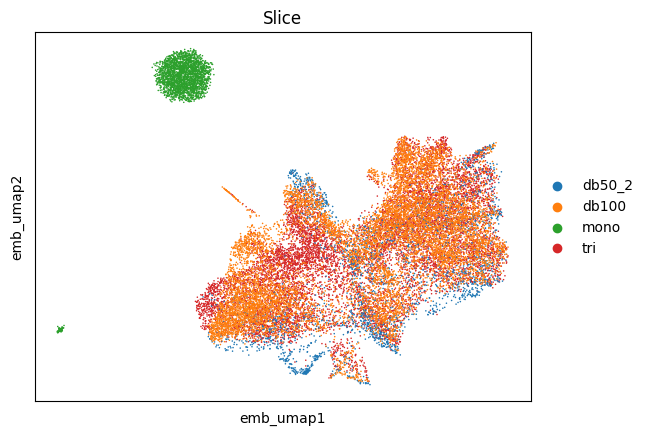

In [14]:
ad_rna_train.obsm['emb'] = gex.obsm["X_model"].copy()
ad_atac_train.obsm['emb'] = other.obsm["X_model"][:ad_rna_train.n_obs]

ad_sat.obsm['emb'] = other.obsm['X_model'][ad_rna_train.n_obs:]

ad_train_mean_enc = sc.AnnData(
    (ad_rna_train.obsm['emb'] + ad_atac_train.obsm['emb'])/2, 
    obs=ad_rna_train.obs.copy(),
    obsm={"emb": (ad_rna_train.obsm['emb'] + ad_atac_train.obsm['emb'])/2}
)

# ad_train_enc = sc.AnnData(
#     ad_atac_train.obsm['emb'], 
#     obs=ad_rna_train.obs.copy(),
#     obsm={"emb": ad_atac_train.obsm['emb']}
# )

ad_test_enc = sc.AnnData(
    ad_sat.obsm['emb'], obs=ad_sat.obs.copy(),
    obsm={'emb':ad_sat.obsm['emb']}
)

ad_mosaic = sc.concat([ad_train_mean_enc, ad_test_enc])
ad_mosaic = get_umap(ad_mosaic, ['emb'])

wrap_warn_plot(ad_mosaic, 'emb_umap', ['Slice'])

In [ ]:
anal_dir = '../../../results/embeddings/CLUE/DBiT-RnaAtac-Atac'
os.makedirs(anal_dir, exist_ok=True)

df = pd.DataFrame(ad_mosaic.obsm['emb'], index=ad_mosaic.obs_names)
df.to_csv(join(anal_dir, 'df_emb.csv'))